<a href="https://colab.research.google.com/github/jagan93550/AI-health-appiontmnet-navigator/blob/main/nlp_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon') np
import re #regular expressions for cleaning the data
import nltk # Natural Language Toolkit (NLTK)
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords # to remove the verbs unwated words
from nltk.sentiment import SentimentIntensityAnalyzer  #
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize # segments
from collections import Counter
from wordcloud import WordCloud # Ensure WordCloud class is imported

# downloading required nltk files


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

creating sample customer review



In [ ]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

print("customer reviews datadsets")
print(df.head())


customer reviews datadsets
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [ ]:
stop_words = set(stopwords.words('english'))
def clean_text(text):
  text = text.lower()
  print('lower case',text)
  text = re.sub(r'[^a-zA-Z\s]','',text)
  print("special character",text)

  words = word_tokenize(text)
  print("tokenization",words)

  words = [word for word in words if word not in stop_words]
  print("stop words",words)

  cleaned_text = " ".join(words)

  return cleaned_text

In [ ]:
nltk.download('punkt_tab')
df['cleaned_review'] = df['Review'].apply(clean_text)
print(df[['Review','cleaned_review']])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


lower case the product quality is excellent and delivery was very fast.
special character the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stop words ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case very bad packaging and the item was damaged.
special character very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stop words ['bad', 'packaging', 'item', 'damaged']
lower case customer service was helpful and responsive.
special character customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stop words ['customer', 'service', 'helpful', 'responsive']
lower case the delivery was delayed and support team did not respond.
special character the delivery was delayed and support team did not respond
tokenization ['the', 'delive

In [ ]:
sia=SentimentIntensityAnalyzer()
def analyze_sentiment(review):
  score=sia.polarity_scores(review)
  compound=score['compound']
  if compound>=0.05:
    return 'positive'
  elif compound<=0.05:
    return 'negative'
  else:
    return 'neutral'
df['sentiment']=df['cleaned_review'].apply(analyze_sentiment)
print("\nsentiment analysis result")
print(df[['Review','sentiment']])


sentiment analysis result
                                              Review sentiment
0  The product quality is excellent and delivery ...  positive
1       Very bad packaging and the item was damaged.  negative
2       Customer service was helpful and responsive.  positive
3  The delivery was delayed and support team did ...  positive
4                  Amazing product. Worth the money.  positive
5      Poor quality product and terrible experience.  negative
6                  Fast shipping and good packaging.  positive
7        The product stopped working after two days.  negative
8               Excellent service and great quality.  positive
9            Late delivery and bad customer support.  negative


In [ ]:
all_words =" ".join(df['cleaned_review'])
word_list =all_words.split()

word_freq=Counter(word_list)
print("\n top 10 common ")
print(word_freq.most_common(10))



 top 10 common 
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [ ]:
negative_reviews = df[df['sentiment'] == 'Negative']
negative_words = " ".join(negative_reviews['cleaned_review'])
negative_words_list=negative_words.split()
complaint_freq=Counter(negative_words_list)
print("\n most common complainted")
print(complaint_freq.most_common(10))



 most common complainted
[]


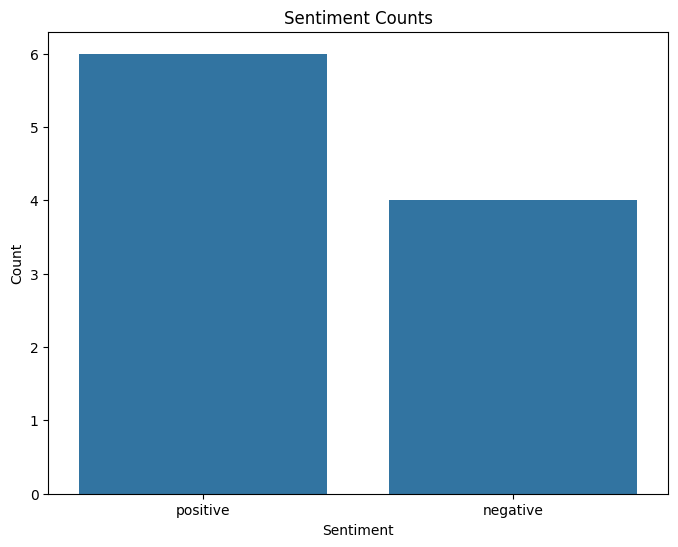

In [ ]:
sentiment_counts = df['sentiment'].value_counts()
plt.figure(figsize=(8,6))
sns.barplot(x=sentiment_counts.index,y=sentiment_counts.values)
plt.title('Sentiment Counts')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

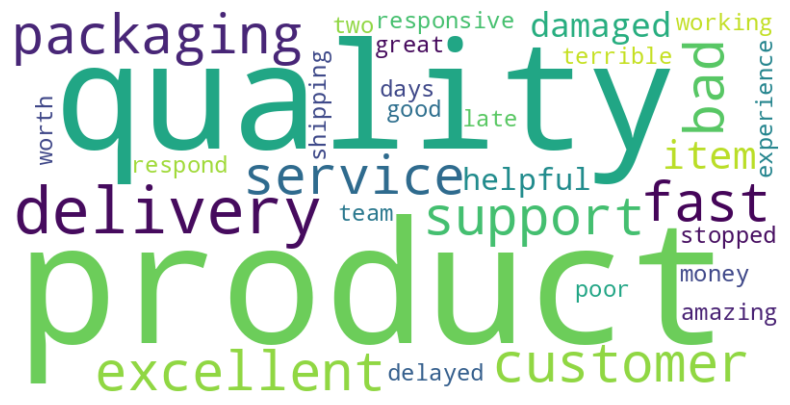

In [ ]:
wordcloud_generator = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_generator, interpolation='bilinear')
plt.axis('off')
plt.show()